# 02 – Baseline Playlists
**Project**: Playlist Optimizer  
**Author**: S33mi  

Build and compare several baseline playlists before running metaheuristics.

Baselines:
1. Random
2. Nearest-Neighbor (greedy similarity to seed)
3. Mood-restricted Nearest-Neighbor
4. Popularity-aware Nearest-Neighbor

All data is loaded via **URL method** (Colab-ready).

## 1. Setup & Imports

In [22]:
import os
from io import BytesIO

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import joblib
from sklearn.metrics.pairwise import cosine_similarity
import warnings

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
pd.set_option("display.max_colwidth", 90)

print("Libraries loaded.")

Libraries loaded.


## 2. Load Artifacts via URL (Colab method)

In [23]:
BASE = "https://raw.githubusercontent.com/S33mi/spotify-music-recommender/main"

URL_PART1 = f"{BASE}/data/processed/spotify_with_clusters_part1.csv"
URL_PART2 = f"{BASE}/data/processed/spotify_with_clusters_part2.csv"
URL_X     = f"{BASE}/data/processed/X_scaled.npy"
URL_MOOD  = f"{BASE}/data/models/mood_labels.pkl"

def download(url: str) -> bytes:
    print(f"Downloading {url} ...")
    r = requests.get(url, timeout=120)
    r.raise_for_status()
    return r.content

# ---- DataFrame (split CSV) ----
print("Loading and merging track metadata ...")
p1 = download(URL_PART1)
p2 = download(URL_PART2)

with open("_part1.tmp", "wb") as f:
    f.write(p1)
with open("_part2.tmp", "wb") as f:
    f.write(p2)

df = pd.concat(
    [pd.read_csv("_part1.tmp"), pd.read_csv("_part2.tmp")],
    ignore_index=True
)
os.remove("_part1.tmp")
os.remove("_part2.tmp")

# ---- Feature matrix ----
X = np.load(BytesIO(download(URL_X)))

# ---- Mood labels ----
mood_labels = joblib.load(BytesIO(download(URL_MOOD)))
if "mood" not in df.columns and "cluster" in df.columns:
    df["mood"] = df["cluster"].map(mood_labels)

assert len(df) == len(X), "Length mismatch between df and X"
print(f"Loaded {len(df)} tracks | X shape = {X.shape}")


Loading and merging track metadata ...
Loaded 89741 tracks | X shape = (89741, 10)


## 3. Scoring Functions
(Same definitions as notebook 01)


In [24]:
def playlist_energy_tempo(df, indices):
    energy = df.iloc[indices]["energy"].values if "energy" in df.columns else np.zeros(len(indices))
    tempo  = df.iloc[indices]["tempo"].values  if "tempo"  in df.columns else np.zeros(len(indices))
    return energy, tempo

def smoothness_score(energy, tempo, w_energy=0.6, w_tempo=0.4):
    if len(energy) < 2:
        return 1.0
    e_jump = np.abs(np.diff(energy)).mean()
    t_jump = (np.abs(np.diff(tempo)) / 50.0).mean()
    return 1.0 / (1.0 + w_energy * e_jump + w_tempo * t_jump)

def seed_similarity_score(X, seed_idx, playlist_indices):
    sims = cosine_similarity(X[seed_idx].reshape(1, -1), X[playlist_indices])[0]
    return float(sims.mean())

def diversity_score(X, playlist_indices):
    if len(playlist_indices) < 2:
        return 1.0
    sim = cosine_similarity(X[playlist_indices])
    triu = sim[np.triu_indices(len(playlist_indices), k=1)]
    return float(1.0 - triu.mean())

def mood_consistency_score(df, playlist_indices, seed_idx):
    if "mood" not in df.columns:
        return 0.5
    seed_mood = df.iloc[seed_idx]["mood"]
    return float((df.iloc[playlist_indices]["mood"] == seed_mood).mean())

def total_playlist_score(
    df, X, seed_idx, playlist_indices,
    w_smooth=0.30, w_sim=0.30, w_div=0.25, w_mood=0.15
):
    energy, tempo = playlist_energy_tempo(df, playlist_indices)
    comps = {
        "smoothness":       smoothness_score(energy, tempo),
        "seed_similarity":  seed_similarity_score(X, seed_idx, playlist_indices),
        "diversity":        diversity_score(X, playlist_indices),
        "mood_consistency": mood_consistency_score(df, playlist_indices, seed_idx),
    }
    comps["total"] = (
        w_smooth * comps["smoothness"]
        + w_sim   * comps["seed_similarity"]
        + w_div   * comps["diversity"]
        + w_mood  * comps["mood_consistency"]
    )
    return comps["total"], comps

## 4. Display & Plot Helpers

In [25]:
def show_playlist(df, indices, title="Playlist"):
    cols = ["track_name", "artists", "track_genre", "popularity"]
    for c in ["mood", "energy", "tempo"]:
        if c in df.columns:
            cols.append(c)
    out = df.iloc[indices][cols].copy()
    out.index = range(1, len(out) + 1)
    print(title)
    display(out)
    return out

def plot_energy_tempo(df, indices, title="Energy & Tempo"):
    energy, tempo = playlist_energy_tempo(df, indices)
    x = np.arange(1, len(indices) + 1)
    fig, ax1 = plt.subplots(figsize=(11, 4))
    ax1.plot(x, energy, "o-", color="steelblue", label="Energy")
    ax1.set_ylabel("Energy", color="steelblue")
    ax1.set_xlabel("Position")
    ax2 = ax1.twinx()
    ax2.plot(x, tempo, "s--", color="darkorange", label="Tempo")
    ax2.set_ylabel("Tempo (BPM)", color="darkorange")
    plt.title(title)
    fig.tight_layout()
    plt.show()

## 5. Baseline Generators

In [26]:
def random_playlist(n_tracks, length, seed_idx=None, random_state=42):
    rng = np.random.default_rng(random_state)
    candidates = np.arange(n_tracks)
    if seed_idx is not None:
        candidates = np.delete(candidates, seed_idx)
    return rng.choice(candidates, size=length, replace=False).tolist()

def nn_playlist(X, seed_idx, length):
    """Top-`length` most similar tracks to the seed."""
    sims = cosine_similarity(X[seed_idx].reshape(1, -1), X)[0]
    sims[seed_idx] = -np.inf
    return np.argsort(sims)[-length:][::-1].tolist()

def mood_nn_playlist(df, X, seed_idx, length):
    """Nearest neighbors restricted to the same mood as the seed."""
    if "mood" not in df.columns:
        return nn_playlist(X, seed_idx, length)
    seed_mood = df.iloc[seed_idx]["mood"]
    same_mood = np.where(df["mood"].values == seed_mood)[0]
    same_mood = same_mood[same_mood != seed_idx]
    if len(same_mood) < length:
        # not enough tracks → fall back to normal NN
        return nn_playlist(X, seed_idx, length)
    sims = cosine_similarity(X[seed_idx].reshape(1, -1), X[same_mood])[0]
    top_local = np.argsort(sims)[-length:][::-1]
    return same_mood[top_local].tolist()

def popular_nn_playlist(df, X, seed_idx, length, min_popularity=40):
    """Nearest neighbors with a popularity floor."""
    sims = cosine_similarity(X[seed_idx].reshape(1, -1), X)[0]
    sims[seed_idx] = -np.inf
    # mask low-popularity tracks
    low_pop = df["popularity"].values < min_popularity
    sims[low_pop] = -np.inf
    return np.argsort(sims)[-length:][::-1].tolist()


## 6. Choose Seed Track

In [27]:
SEED_QUERY = "blinding lights"   # change this
PLAYLIST_LENGTH = 12             # Change SEED_QUERY and PLAYLIST_LENGTH as you like.

mask = df["track_name"].str.lower().str.contains(SEED_QUERY.lower(), na=False)
if mask.sum() == 0:
    seed_pos = 0
    print("Query not found – using first track.")
else:
    seed_pos = df.index.get_loc(mask.idxmax())

seed = df.iloc[seed_pos]
print("Seed track:")
print(f"  {seed['track_name']} — {seed['artists']}")
print(f"  Genre: {seed.get('track_genre')} | Mood: {seed.get('mood')} | Pop: {seed['popularity']}")

Seed track:
  Blinding Lights — Kidz Bop Kids
  Genre: children | Mood: Acoustic / Chill | Pop: 0.0


## 7. Generate All Baselines

In [28]:
baselines = {}

# 1. Random
baselines["Random"] = random_playlist(len(df), PLAYLIST_LENGTH, seed_idx=seed_pos, random_state=42)

# 2. Nearest-Neighbor
baselines["Nearest-Neighbor"] = nn_playlist(X, seed_pos, PLAYLIST_LENGTH)

# 3. Mood-restricted NN
baselines["Mood-NN"] = mood_nn_playlist(df, X, seed_pos, PLAYLIST_LENGTH)

# 4. Popularity-aware NN
baselines["Popular-NN"] = popular_nn_playlist(df, X, seed_pos, PLAYLIST_LENGTH, min_popularity=40)

print("Baselines generated.")

Baselines generated.


## 8. Score & Display Each Baseline


Random  |  Total score = nan
Random


,track_name,artists,track_genre,popularity,mood,energy,tempo
1,Remedy,Seether,grunge,70.0,Upbeat Electronic,1.237481,0.190776
2,Hands Up,City Wolf,blues,53.0,Upbeat Electronic,0.952996,1.256308
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Parisienne Walkways,Gary Moore;Phil Lynott,blues,55.0,Happy Pop,-1.525536,1.739617
8,Desilusão,Cleverson Silva;Marsena,groove,24.0,Acoustic / Chill,0.691893,-0.864495
9,Pula,Tihuana,brazil,49.0,Acoustic / Chill,1.179025,0.501295
10,NaN,NaN,NaN,NaN,NaN,NaN,NaN


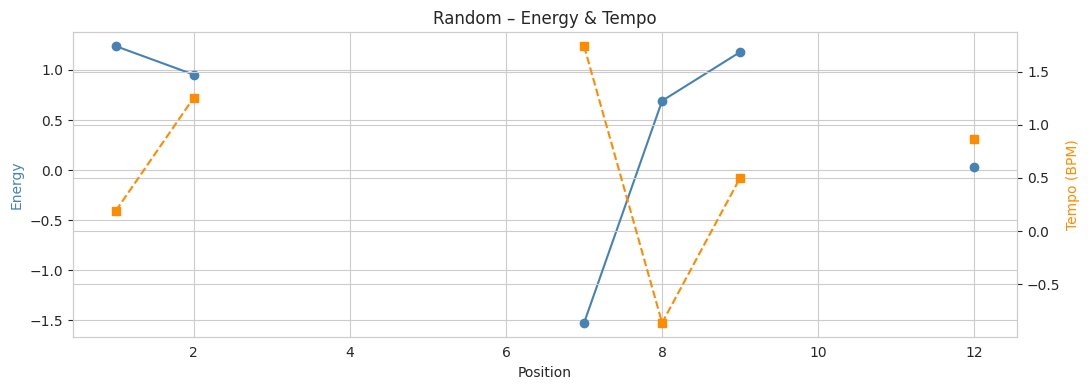


Nearest-Neighbor  |  Total score = nan
Nearest-Neighbor


,track_name,artists,track_genre,popularity,mood,energy,tempo
1,Atrakce,PAWLIE POIZN;Medooza,emo,36.0,Acoustic / Chill,0.391819,1.588907
2,My Person,Spencer Crandall,country,61.0,Acoustic / Chill,0.461966,1.457886
3,Mob Rule,Bad//Dreems,garage,29.0,Acoustic / Chill,0.621745,1.490093
4,My Person,Spencer Crandall,country,55.0,Acoustic / Chill,0.477554,1.459347
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,1+1,Ready Kirken,folk,46.0,Acoustic / Chill,0.306083,1.757979
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,Manohari,Divya Kumar;Neeti Mohan,folk,55.0,Acoustic / Chill,0.645128,1.259728
10,The Middle,Jimmy Eat World,alt-rock,0.0,Acoustic / Chill,0.832187,1.331215


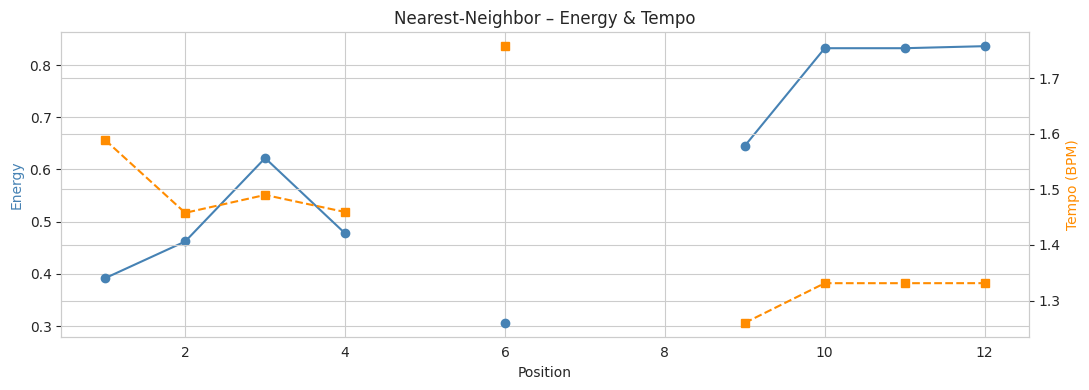


Mood-NN  |  Total score = 0.730
Mood-NN


,track_name,artists,track_genre,popularity,mood,energy,tempo
1,Atrakce,PAWLIE POIZN;Medooza,emo,36.0,Acoustic / Chill,0.391819,1.588907
2,My Person,Spencer Crandall,country,61.0,Acoustic / Chill,0.461966,1.457886
3,Mob Rule,Bad//Dreems,garage,29.0,Acoustic / Chill,0.621745,1.490093
4,My Person,Spencer Crandall,country,55.0,Acoustic / Chill,0.477554,1.459347
5,1+1,Ready Kirken,folk,46.0,Acoustic / Chill,0.306083,1.757979
6,Manohari,Divya Kumar;Neeti Mohan,folk,55.0,Acoustic / Chill,0.645128,1.259728
7,The Middle,Jimmy Eat World,alt-rock,0.0,Acoustic / Chill,0.832187,1.331215
8,The Middle,Jimmy Eat World,alt-rock,0.0,Acoustic / Chill,0.832187,1.331215
9,The Middle,Jimmy Eat World,alt-rock,81.0,Acoustic / Chill,0.836084,1.331248
10,Kahani Baaki Hai,Divya Kumar,folk,34.0,Acoustic / Chill,0.723069,1.593489


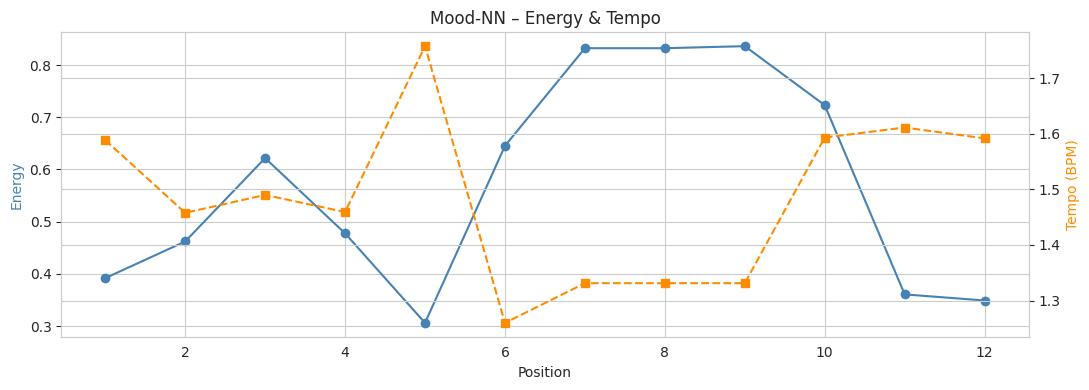


Popular-NN  |  Total score = nan
Popular-NN


,track_name,artists,track_genre,popularity,mood,energy,tempo
1,My Person,Spencer Crandall,country,61.0,Acoustic / Chill,0.461966,1.457886
2,My Person,Spencer Crandall,country,55.0,Acoustic / Chill,0.477554,1.459347
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1+1,Ready Kirken,folk,46.0,Acoustic / Chill,0.306083,1.757979
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Manohari,Divya Kumar;Neeti Mohan,folk,55.0,Acoustic / Chill,0.645128,1.259728
8,The Middle,Jimmy Eat World,alt-rock,81.0,Acoustic / Chill,0.836084,1.331248
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10,NaN,NaN,NaN,NaN,NaN,NaN,NaN


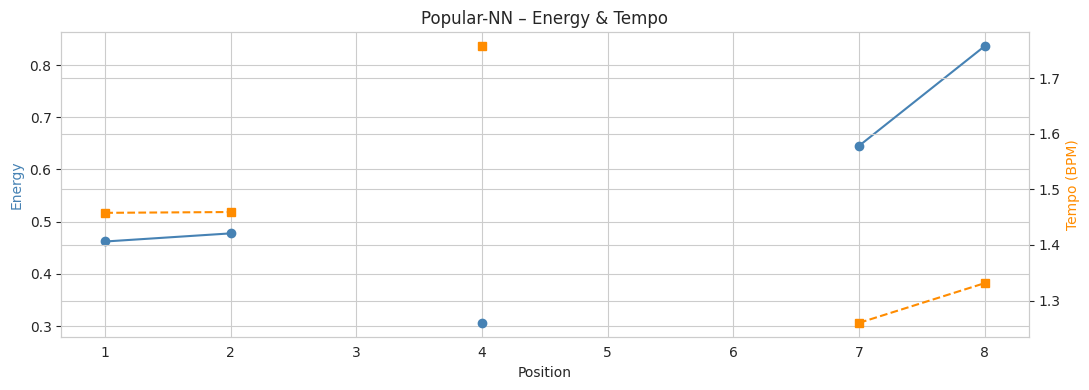

In [29]:
results = []

for name, indices in baselines.items():
    score, comps = total_playlist_score(df, X, seed_pos, indices)
    results.append({
        "baseline": name,
        **{k: round(v, 3) for k, v in comps.items()}
    })
    print(f"\n{'='*60}")
    print(f"{name}  |  Total score = {comps['total']:.3f}")
    show_playlist(df, indices, title=name)
    plot_energy_tempo(df, indices, title=f"{name} – Energy & Tempo")

## 9. Comparison Table

,smoothness,seed_similarity,diversity,mood_consistency,total
baseline,,,,,
Random,NaN,0.359,0.871,0.167,NaN
Nearest-Neighbor,NaN,0.982,0.032,0.750,NaN
Mood-NN,0.921,0.980,0.039,1.000,0.73
Popular-NN,NaN,0.979,0.039,0.417,NaN


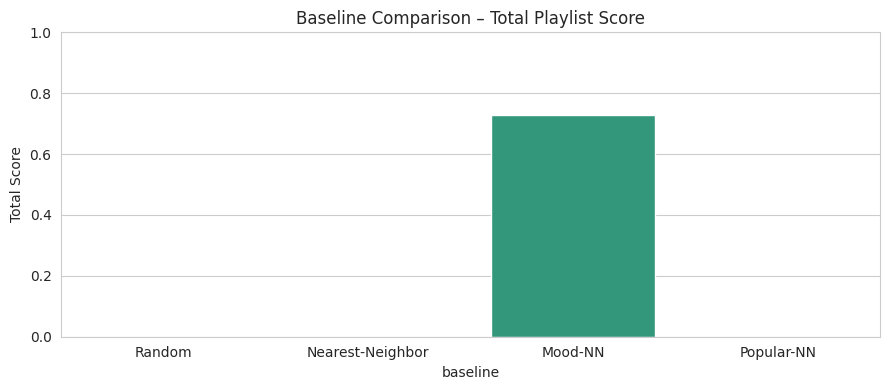

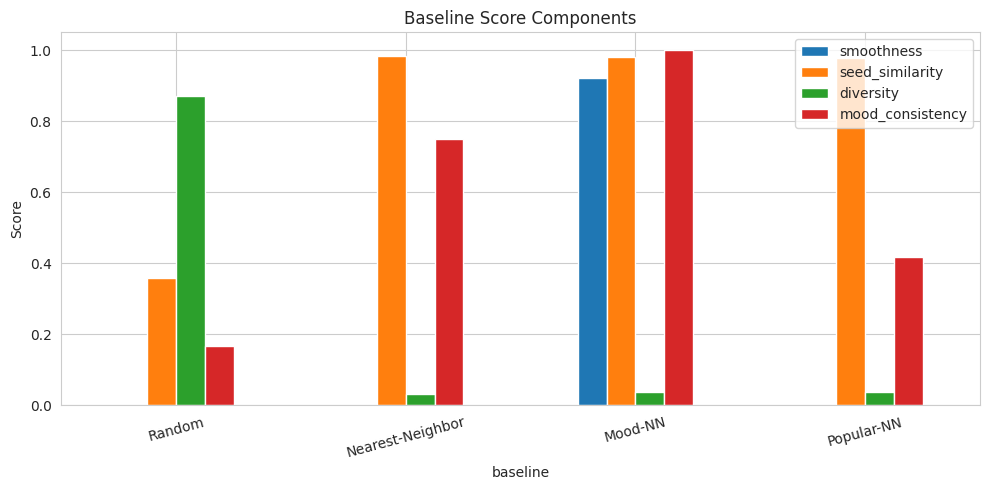

In [30]:
results_df = pd.DataFrame(results).set_index("baseline")
display(results_df)

# Bar plot of total scores
plt.figure(figsize=(9, 4))
sns.barplot(x=results_df.index, y=results_df["total"], palette="viridis")
plt.ylabel("Total Score")
plt.title("Baseline Comparison – Total Playlist Score")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

# Component breakdown (stacked / grouped)
comp_cols = ["smoothness", "seed_similarity", "diversity", "mood_consistency"]
results_df[comp_cols].plot(kind="bar", figsize=(10, 5))
plt.title("Baseline Score Components")
plt.ylabel("Score")
plt.xticks(rotation=15)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

## 10. (Optional) Save baseline results

In [31]:
os.makedirs("data", exist_ok=True)
results_df.to_csv("data/baseline_scores.csv")
print("Saved data/baseline_scores.csv")

Saved data/baseline_scores.csv


## 11. Summary

| Baseline | Idea |
|----------|------|
| Random | Uniform random tracks (sanity check) |
| Nearest-Neighbor | Pure content similarity to seed |
| Mood-NN | Same mood cluster + similarity |
| Popular-NN | Similarity + popularity filter |

Change `SEED_QUERY` and `PLAYLIST_LENGTH` as you like.

These scores are the reference points for the Genetic Algorithm and Simulated Annealing notebooks.

**Next**: `03_genetic_algorithm.ipynb`